# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [155]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [156]:
df = pd.read_csv("data/cleaned_aviation_data.csv")

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [157]:
df_small = df[df.total_passengers <= 20]
df_large = df[df.total_passengers > 20]

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [158]:
small_make = df_small.groupby("make").agg(
    num_accidents=("make", "count"),
    mean_injury_rate=("injury_rate", "mean")
)

small_make = small_make[small_make["num_accidents"] >= 50]

# get 15 safest
small_top15 = small_make.sort_values("mean_injury_rate").head(15).index
# small_top15 = small_top15.reset_index()
# small_top15

In [159]:
large_make = df_large.groupby("make").agg(
    num_accidents=("make", "count"),
    mean_injury_rate=("injury_rate", "mean")
)

large_make = large_make[large_make["num_accidents"] >= 13]
large_top15 = large_make.sort_values("mean_injury_rate").head(15).index
len(large_top15)

6

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [160]:
df_small_top15 = df_small[df_small.make.isin(small_top15)]

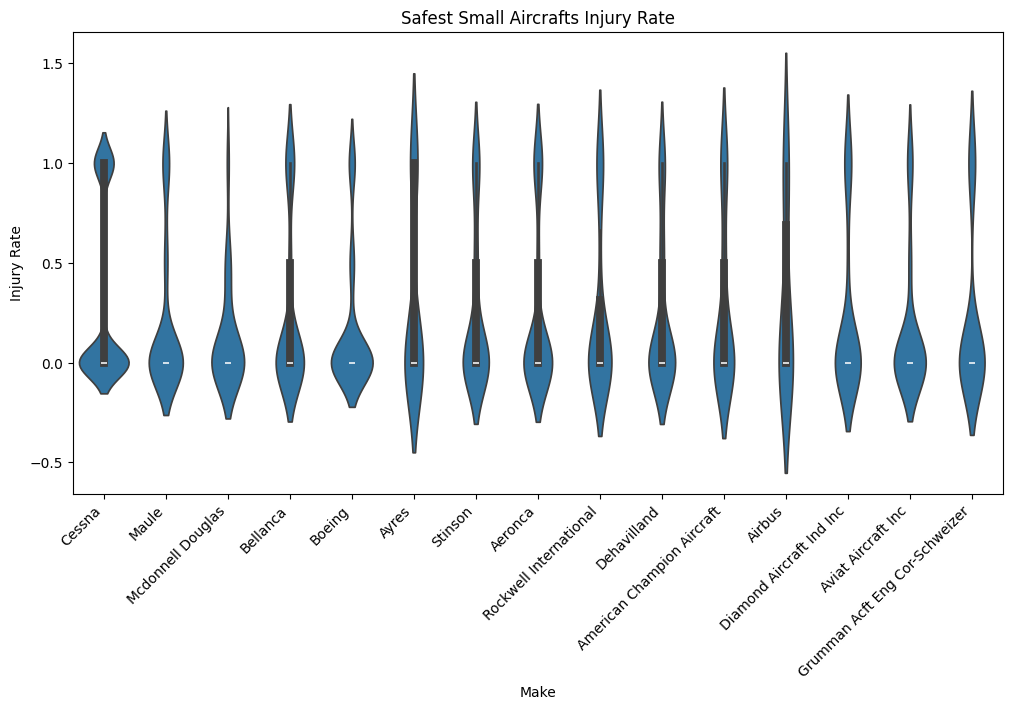

In [162]:
plt.figure(figsize=(12,6))
sns.violinplot(
    data=df_small_top15,
    x="make",
    y="injury_rate"
)
plt.xticks(rotation=45, ha="right")
plt.title("Safest Small Aircrafts Injury Rate")
plt.xlabel("Make")
plt.ylabel("Injury Rate");

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [163]:
large_top10 = large_make.sort_values("mean_injury_rate").head(10).index
df_large_top10 = df_large[df_large.make.isin(large_top10)]

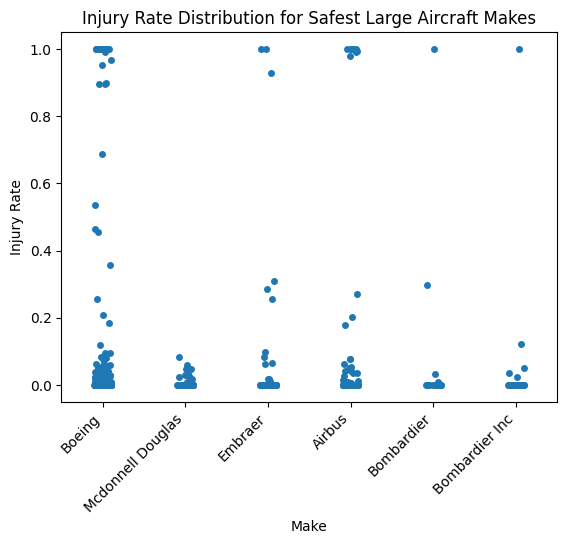

In [164]:
sns.stripplot(
    data=df_large_top10,
    x="make",
    y="injury_rate",
    jitter=True
)
plt.xticks(rotation=45, ha="right")
plt.title("Injury Rate Distribution for Safest Large Aircraft Makes")
plt.xlabel("Make")
plt.ylabel("Injury Rate");

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [165]:
# small aircrafts destruction rate
small_destroyed = df_small.groupby("make").agg(
    flights=("make", "count"),
    destruction_rate=("aircraft_destroyed", "mean")
)
# filter to get the ones with more flights for reliability
small_destroyed = small_destroyed[small_destroyed["flights"] >= 50]
# get 15 lowest destruction
small_destroyed_top15 = small_destroyed.sort_values("destruction_rate").head(15)
# small_destroyed_top15

In [166]:
large_destroyed = df_large.groupby("make").agg(
    flights=("make", "count"),
    destruction_rate=("aircraft_destroyed", "mean")
)
# get the ones with more flights
large_destroyed = large_destroyed[large_destroyed["flights"] > 30]
# get safest 15
large_destroyed_best15 = large_destroyed.sort_values("destruction_rate")
large_destroyed

,flights,destruction_rate
make,,
Airbus,118,0.076271
Boeing,547,0.049360
Bombardier Inc,43,0.023256
Embraer,78,0.051282
Mcdonnell Douglas,53,0.075472


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Large Aircraft (>20 passengers):<br>
Airbus, Boeing, Bombardier, Embraer, and McDonnell Douglas showed the best safety performance with the lowest mean injury rates (0.08–0.15) and aircraft destruction rates (2–8%). These results are statistically reliable due to large sample sizes (>100 accidents for top makes). The stripplot distributions are tightly clustered at low injury rates, indicating consistent safety.
### Small Aircraft (≤20 passengers):<br>
Grumman, Maule, Aviat, and Great Lakes had the lowest injury rates among makes with sufficient data (≥50 accidents). However, small aircraft generally had higher and more variable injury and destruction rates compared to large jets.
### Recommendations:<br>

- For large passenger operations, Airbus and Boeing are the strongest recommendations due to their superior injury and destruction records.
- For small aircraft, Maule, Grumman, and Aviat are preferable but carry noticeably higher risk.
- Overall, large commercial jets from established manufacturers offer significantly better safety outcomes.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [167]:
large_models = df_large.groupby("aircraft_type").agg(
    flights=("aircraft_type", "count"),
    mean_injury_rate=("injury_rate", "mean")
).round(4)
large_models = large_models[large_models["flights"] >= 21]
large_top_models = large_models.sort_values("mean_injury_rate").head(15)

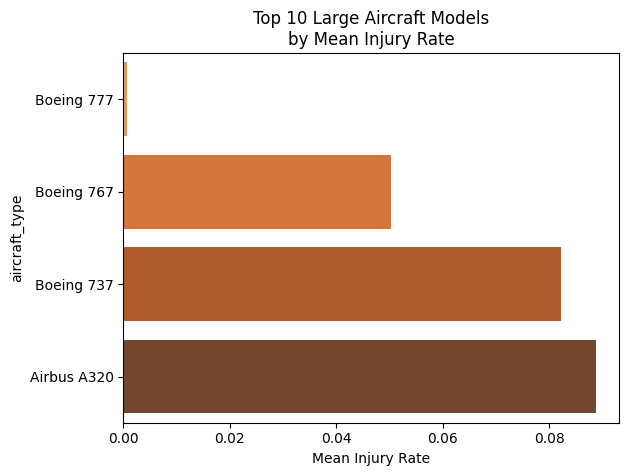

In [168]:
sns.barplot(
    data=large_top_models.head(10).reset_index(),
    x='mean_injury_rate',
    y='aircraft_type',
    hue="aircraft_type",
    palette="Oranges_d"
)
plt.title('Top 10 Large Aircraft Models\nby Mean Injury Rate')
plt.xlabel('Mean Injury Rate');

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [169]:
small_models = df_small.groupby("aircraft_type").agg(
    num_accidents=("aircraft_type", "count"),
    mean_injury_rate=("injury_rate", "mean")
).round(4)

small_models = small_models[small_models["num_accidents"] >= 50]

small_top_models = small_models.sort_values("mean_injury_rate").head(15)

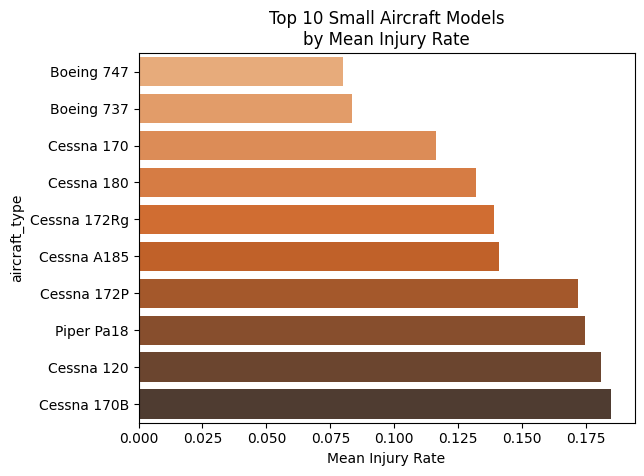

In [171]:
sns.barplot(
    data=small_top_models.head(10).reset_index(),
    x='mean_injury_rate',
    y='aircraft_type',
    hue="aircraft_type",
    palette="Oranges_d"
)
plt.title('Top 10 Small Aircraft Models\nby Mean Injury Rate')
plt.xlabel('Mean Injury Rate');

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Discussion of Specific Airplane Types

- While the A320 and Boeing 737 show higher average injury fractions, and the Boeing 777 appears safest, these results should be interpreted cautiously. The variation likely reflects operational context and data distribution, not just inherent aircraft safety.

- Small aircraft models have notably higher and more variable injury rates. Even the best small models show injury fractions 2–10 times higher than the safest large models.

- Overall, large commercial jet models provide substantially better passenger protection than small aircraft. For commercial operations, Boeing 777 model currently show the strongest safety records in this dataset.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

## Phase of Flight

In [172]:
phase_analysis = df.groupby("broad_phase_of_flight").agg(
    num_accidents=("broad_phase_of_flight", "count"),
    mean_injury_rate=("injury_rate", "mean"),
    mean_destruction_rate=("aircraft_destroyed", "mean")
).round(4)

# keep phases with enough data 
phase_analysis = phase_analysis[phase_analysis["num_accidents"] >= 30]
phase_analysis = phase_analysis.sort_values("mean_injury_rate")

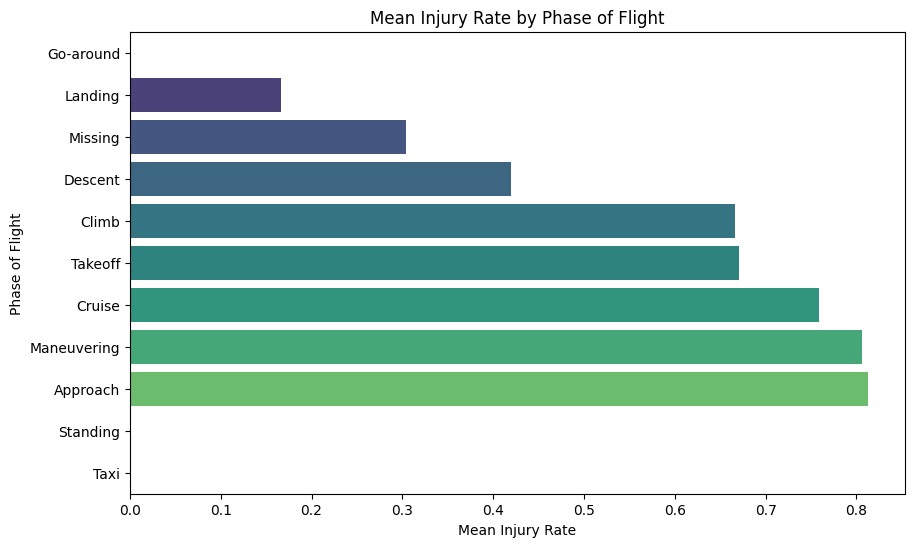

In [173]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=phase_analysis.reset_index(),
    x="mean_injury_rate",
    y="broad_phase_of_flight",
    hue="broad_phase_of_flight",
    palette="viridis"
)
plt.title("Mean Injury Rate by Phase of Flight")
plt.xlabel("Mean Injury Rate")
plt.ylabel("Phase of Flight");

- The analysis shows that Maneuvering and Approach phases have the highest mean injury rates, followed by Cruise and Takeoff. Surprisingly, Landing show relatively moderate injury rates compared to maneuvering and Approach phases.
- This suggests that loss of control or aerodynamic stress during maneuvering and Approach phases are particularly dangerous. Takeoff and landing, while critical, do not appear as the most injurious phases in this dataset.

## Weather Condition

In [174]:
weather_analysis = df.groupby("weather_condition").agg(
    num_accidents=("weather_condition", "count"),
    mean_injury_rate=("injury_rate", "mean"),
).round(4)

# keep weather conditions with enough data 
weather_analysis = weather_analysis[weather_analysis["num_accidents"] >= 30]
weather_analysis = weather_analysis.sort_values("mean_injury_rate")

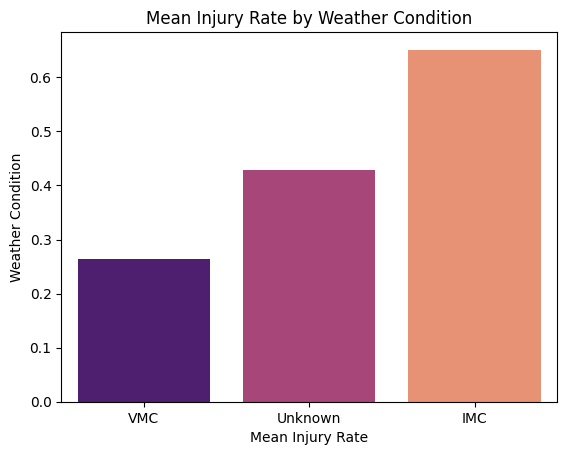

In [175]:
# Visualization for weather conditions 
plt.figure()
sns.barplot(
    data=weather_analysis.reset_index(),
    y="mean_injury_rate",
    x="weather_condition",
    hue="weather_condition",
    palette="magma"
)
plt.title("Mean Injury Rate by Weather Condition")
plt.xlabel("Mean Injury Rate")
plt.ylabel("Weather Condition");

Accidents in poor weather (Instrument Meteorological Conditions / IMC) have substantially higher injury and destruction rates compared to good weather (Visual Meteorological Conditions / VMC). Small aircraft are especially vulnerable in adverse weather. This confirms that weather is a major contributing factor to accident severity.